<a href="https://colab.research.google.com/github/Brando3331/Brando3331.github.io/blob/Ri/%D0%9F%D0%A0%D0%90%D0%9A%D0%A2%D0%98%D0%9A%D0%90_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.4 MB/s eta 0:00:00


### Где искать результаты?
Все графики (F1_curve, Confusion Matrix) и метрики сохраняются в папку `my_training/yolov8_roboflow/`.

*   **mAP50 / mAP50-95**: Средняя точность (чем выше, тем лучше).
*   **Precision**: Насколько точно модель находит объекты (мало ложных срабатываний).
*   **Recall**: Как много объектов из существующих модель смогла найти.

In [3]:
import os
from ultralytics import YOLO

# 1. Путь к данным (теперь dataset точно определен после загрузки из Roboflow)
dataset_location = dataset.location
path_to_yaml = os.path.join(dataset_location, "data.yaml")
print(f"Путь к датасету: {dataset_location}")

# 2. Инициализация и Обучение
if os.path.exists(path_to_yaml):
    # Загружаем модель Nano
    model = YOLO("yolov8n.pt")

    # Запуск обучения
    print("--- Начинаем обучение ---")
    model.train(
        data=path_to_yaml,
        epochs=25,
        imgsz=640,
        batch=16,
        name="yolov8_roboflow",
        project="my_training"
    )

    # 3. Тестирование
    test_images_path = os.path.join(dataset_location, "test/images")
    if os.path.exists(test_images_path):
        print("--- Тестируем модель ---")
        model.predict(source=test_images_path, save=True, conf=0.25)
        print(f"\nОбучение завершено! Результаты, графики и фото сохранены в папку: my_training/yolov8_roboflow")
    else:
        print(f"Папка с тестами не найдена: {test_images_path}")
else:
    print(f"Ошибка: Файл {path_to_yaml} не найден! Дождитесь окончания загрузки датасета.")

Путь к датасету: /content/dataset-1
--- Начинаем обучение ---
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_roboflow, nbs=64, nms=False, opset=None, opti

### 4. Анализ результатов обучения
Посмотрим на графики точности и потерь, которые сохранились в процессе обучения.

--- Графики обучения (Loss, mAP) ---


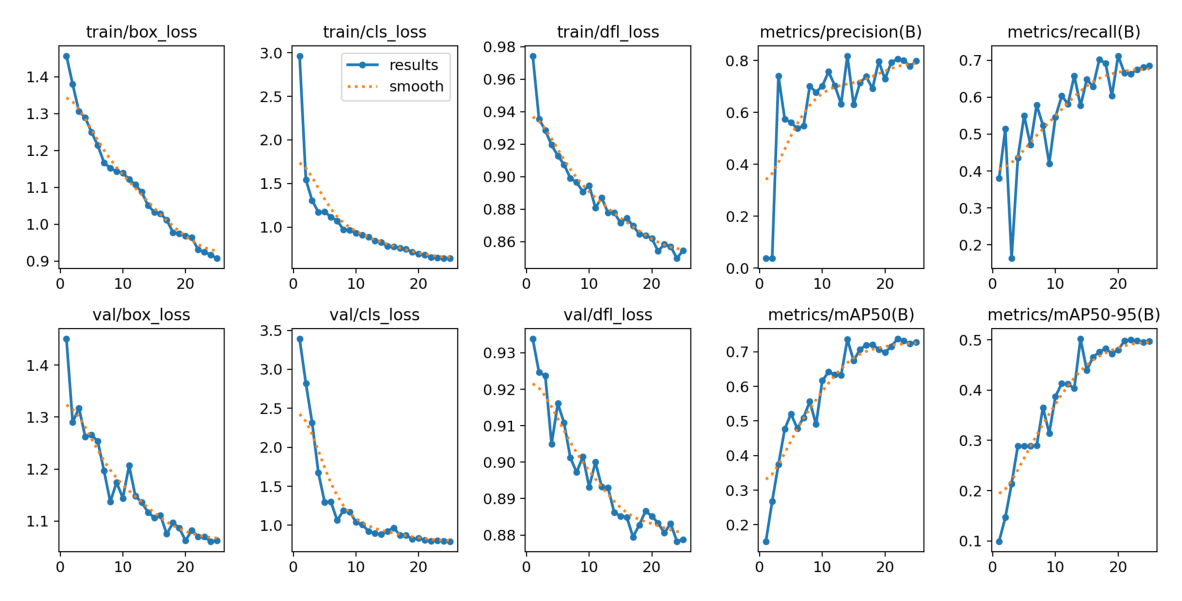


--- Матрица ошибок (Confusion Matrix) ---


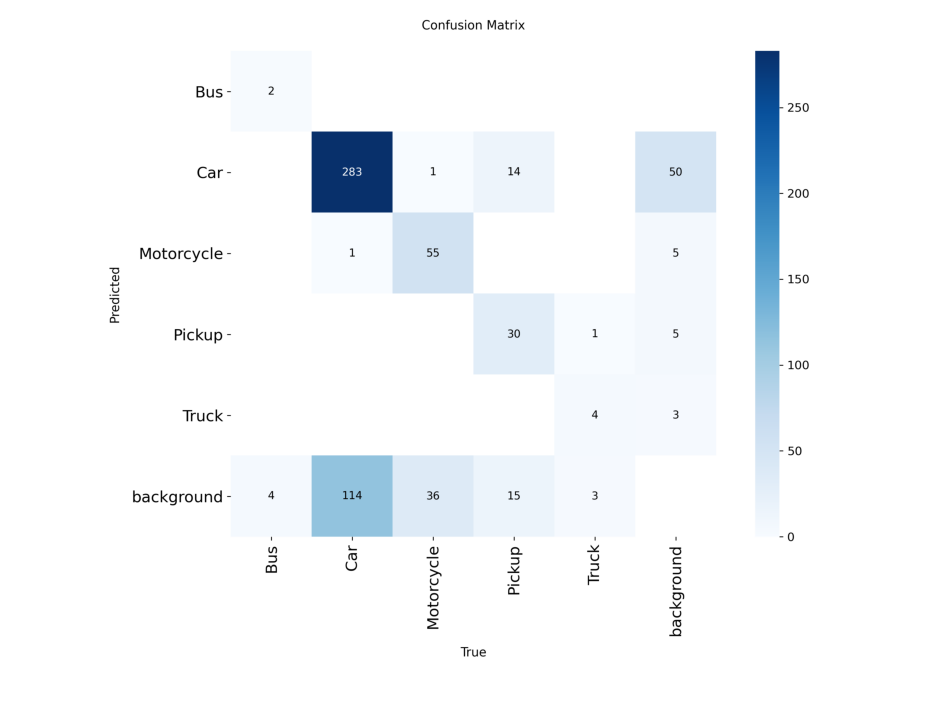

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Исправленный путь к результатам на основе логов обучения
results_path = '/content/runs/detect/my_training/yolov8_roboflow/results.png'
confusion_path = '/content/runs/detect/my_training/yolov8_roboflow/confusion_matrix.png'

if os.path.exists(results_path):
    print("--- Графики обучения (Loss, mAP) ---")
    plt.figure(figsize=(15, 10))
    plt.imshow(mpimg.imread(results_path))
    plt.axis('off')
    plt.show()

if os.path.exists(confusion_path):
    print("\n--- Матрица ошибок (Confusion Matrix) ---")
    plt.figure(figsize=(12, 10))
    plt.imshow(mpimg.imread(confusion_path))
    plt.axis('off')
    plt.show()
else:
    print(f"Файлы не найдены в {os.path.dirname(results_path)}. Проверьте папку runs/.")

### 5. Визуализация предсказаний
Выведем несколько случайных изображений, на которых модель отметила найденные объекты.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Найдено изображений с предсказаниями: 13


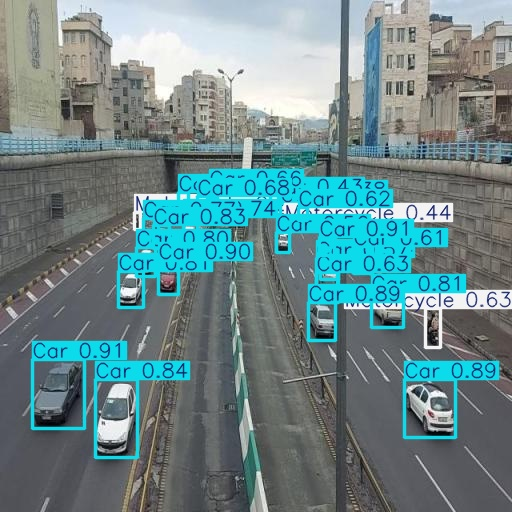

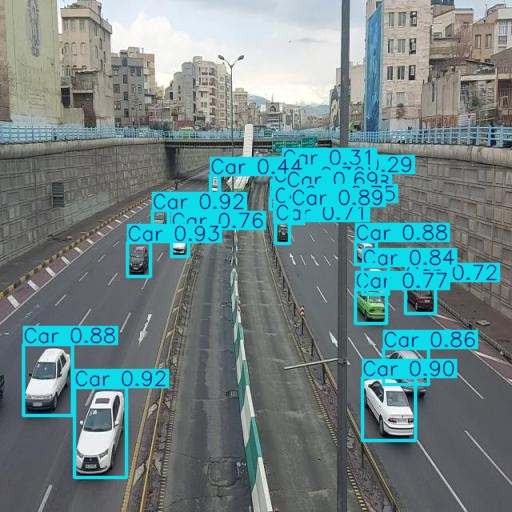

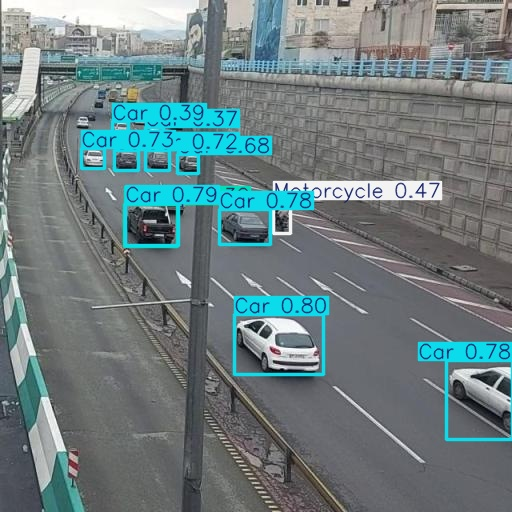

In [5]:
import glob
from IPython.display import Image, display

# Ищем все сохраненные предсказания
predict_images = glob.glob('/content/runs/detect/predict/*.jpg')

if predict_images:
    print(f"Найдено изображений с предсказаниями: {len(predict_images)}")
    # Показываем первые 3 для примера
    for img_path in predict_images[:3]:
        display(Image(filename=img_path, width=600))
else:
    print("Изображения с предсказаниями не найдены. Проверьте папку runs/detect/predict")

In [13]:
!find /content -name "data.yaml"

In [2]:
!pip install roboflow

from roboflow import Roboflow
# 1. Получите ваш API ключ здесь: https://app.roboflow.com/adrian-rosebrock/fast-food-classification/model/1
# 2. Скопируйте код 'Snippet' для YOLOv8

rf = Roboflow(api_key="1aU8DWhmYw3o8NTZkso7")
project = rf.workspace("s-workspace-vecqk").project("dataset-rjqhq")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset-1 in yolov8:: 100%|██████████| 895/895 [00:00<00:00, 8819.08it/s]
